<a href="https://colab.research.google.com/github/DebopriyoKarmakar/Walmart-Store-Sales-Demand-Forecasting/blob/main/Walmart_Store_Sales_Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the clean dataset from Excel/Power Query output
df = pd.read_csv("/content/walmart_master.csv", parse_dates=["Date"])
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

print(df.shape)
print(df.info())
print(df.describe())
print(df.isna().sum())

(421570, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 22 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Store          421570 non-null  int64         
 1   Dept           421570 non-null  int64         
 2   Date           421570 non-null  datetime64[ns]
 3   Weekly_Sales   421570 non-null  float64       
 4   IsHoliday      421570 non-null  bool          
 5   Type           421570 non-null  object        
 6   Size           421570 non-null  int64         
 7   Temperature    421570 non-null  float64       
 8   Fuel_Price     421570 non-null  float64       
 9   MarkDown1      421570 non-null  int64         
 10  MarkDown2      421570 non-null  int64         
 11  MarkDown3      421570 non-null  int64         
 12  MarkDown4      421570 non-null  int64         
 13  MarkDown5      421570 non-null  int64         
 14  CPI            421570 non-null  float64

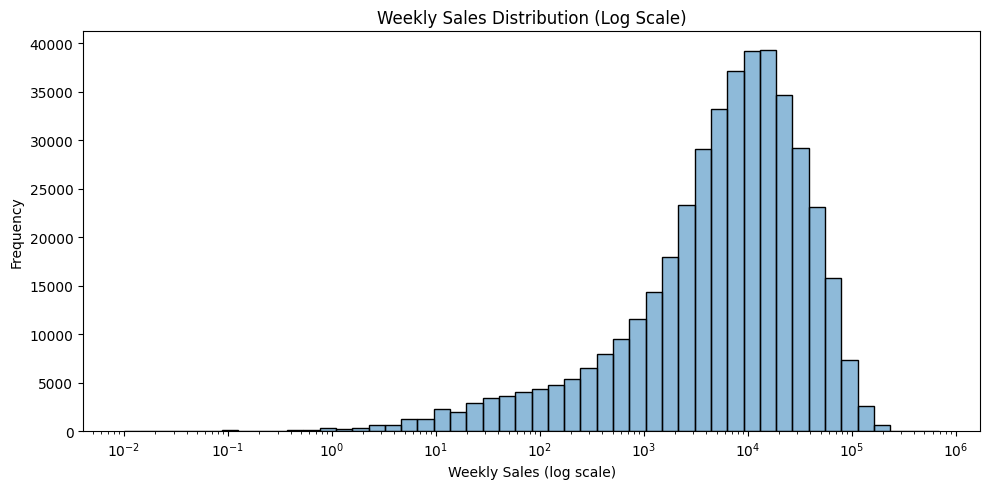

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(df['Weekly_Sales'], log_scale=True, bins=50, kde=True)
plt.title('Weekly Sales Distribution (Log Scale)')
plt.xlabel('Weekly Sales (log scale)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('histogram_weekly_sales.png')
plt.show()

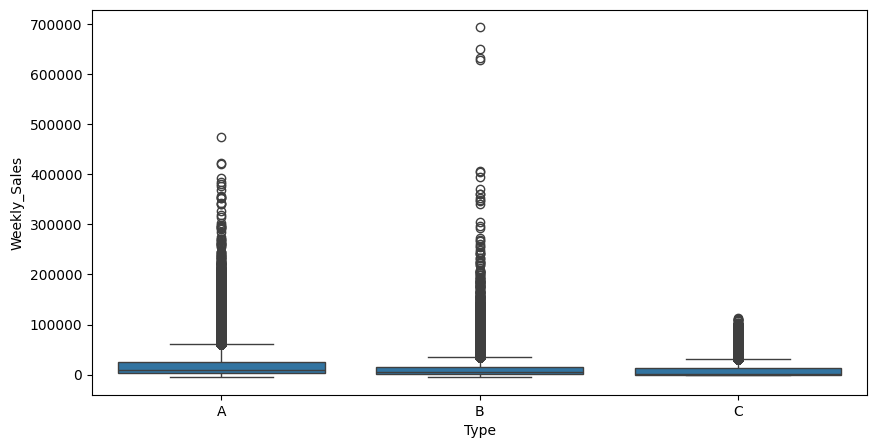

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Type', y='Weekly_Sales')
plt.savefig('boxplot_type.png')
plt.show()

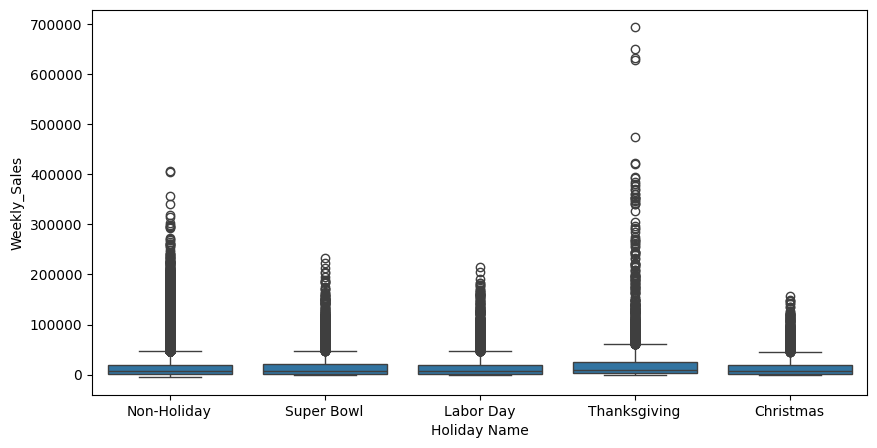

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Holiday Name', y='Weekly_Sales')
plt.savefig('boxplot_type.png')
plt.show()

In [31]:
mean_sales = df['Weekly_Sales'].mean()
median_sales = df['Weekly_Sales'].median()
print(f"Mean Weekly Sales: ${mean_sales:,.0f}")
print(f"Median Weekly Sales: ${median_sales:,.0f}")
print(f"Ratio: {mean_sales/median_sales:.2f}x")

Mean Weekly Sales: $15,981
Median Weekly Sales: $7,612
Ratio: 2.10x


In [32]:
type_sales = df.groupby('Type')['Weekly_Sales'].sum()
print(type_sales)
print(f"\nType A share: {type_sales['A']/type_sales.sum()*100:.1f}%")

Type
A    4.331015e+09
B    2.000701e+09
C    4.055035e+08
Name: Weekly_Sales, dtype: float64

Type A share: 64.3%


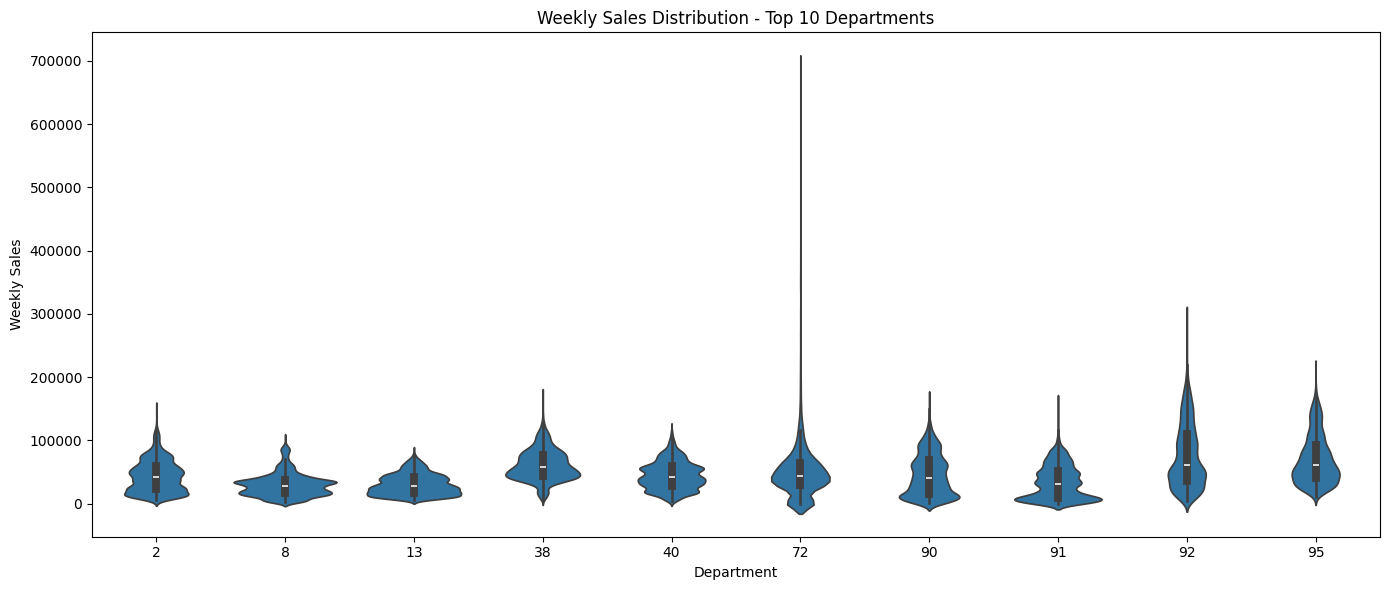

In [33]:
top10_depts = df.groupby('Dept')['Weekly_Sales'].sum().nlargest(10).index
df_top10 = df[df['Dept'].isin(top10_depts)]

plt.figure(figsize=(14,6))
sns.violinplot(data=df_top10, x='Dept', y='Weekly_Sales')
plt.title('Weekly Sales Distribution - Top 10 Departments')
plt.xlabel('Department')
plt.ylabel('Weekly Sales')
plt.tight_layout()
plt.savefig('violin_top10_depts.png')
plt.show()

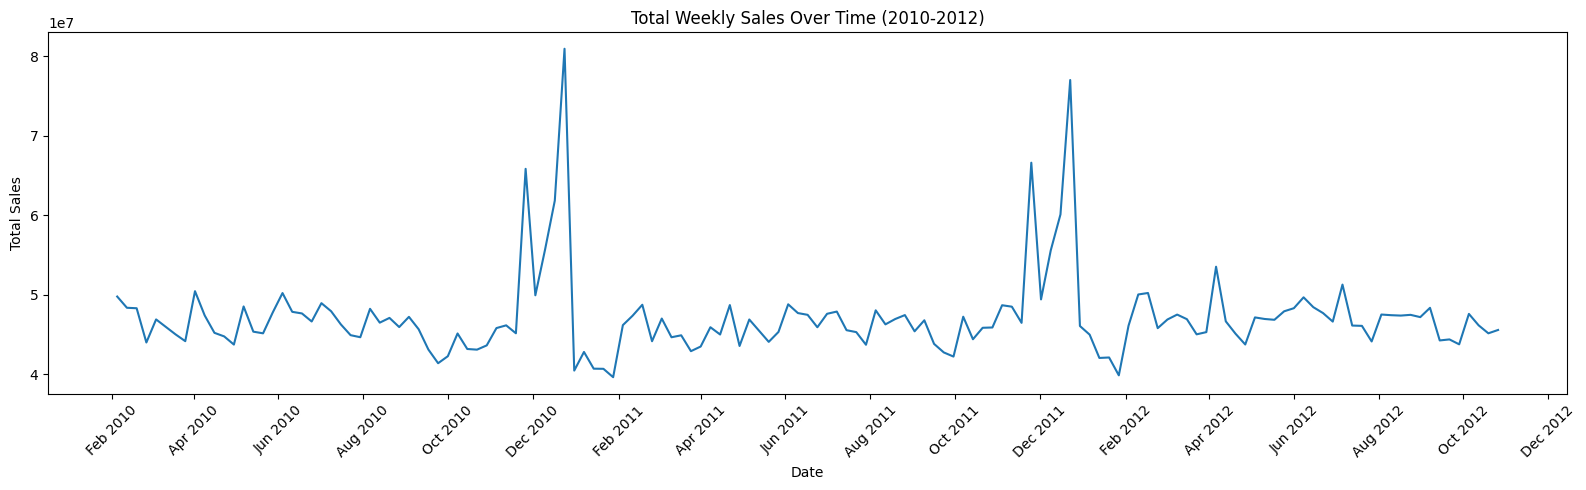

In [34]:
import matplotlib.dates as mdates

weekly_total = df.groupby('Date')['Weekly_Sales'].sum().sort_index()

plt.figure(figsize=(16,5))
plt.plot(weekly_total.index, weekly_total.values)
plt.title('Total Weekly Sales Over Time (2010-2012)')
plt.xlabel('Date')
plt.ylabel('Total Sales')

# Fix x-axis
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # show every 2 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format like "Jan 2010"
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('time_series_trend.png')
plt.show()

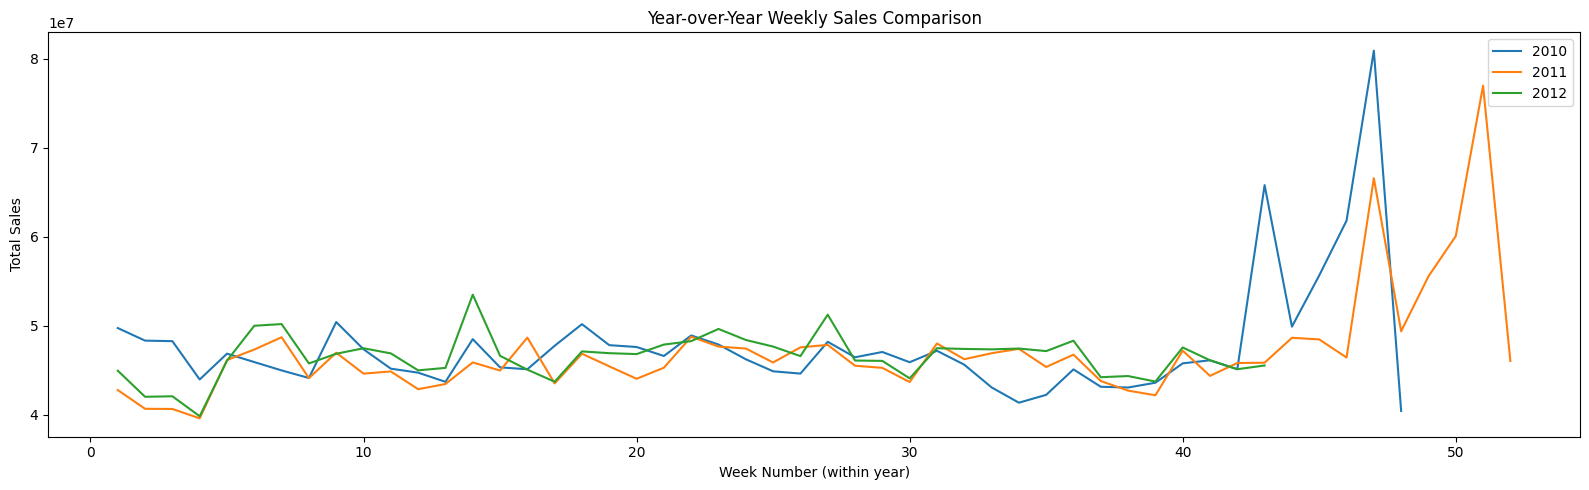

In [35]:
df['Year'] = df['Date'].dt.year
df['WeekNum'] = df.groupby('Year')['Date'].rank(method='dense').astype(int)

yearly_weekly = df.groupby(['Year', 'WeekNum'])['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(16,5))
for year in sorted(yearly_weekly['Year'].unique()):
    subset = yearly_weekly[yearly_weekly['Year'] == year]
    plt.plot(subset['WeekNum'], subset['Weekly_Sales'], label=str(year))

plt.title('Year-over-Year Weekly Sales Comparison')
plt.xlabel('Week Number (within year)')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.savefig('yoy_overlay.png')
plt.show()

In [36]:
# holiday names in the data
holiday_map = {
    '2010-02-12': 'Super Bowl', '2011-02-11': 'Super Bowl', '2012-02-10': 'Super Bowl',
    '2010-09-10': 'Labor Day', '2011-09-09': 'Labor Day', '2012-09-07': 'Labor Day',
    '2010-11-26': 'Thanksgiving', '2011-11-25': 'Thanksgiving',
    '2010-12-31': 'Christmas', '2011-12-30': 'Christmas'
}

df['Date_str'] = df['Date'].dt.strftime('%Y-%m-%d')
df['Holiday_Name'] = df['Date_str'].map(holiday_map)
df['Holiday_Name'] = df['Holiday_Name'].fillna('Non-Holiday')

In [37]:
# Compare average sales per holiday
holiday_means = df.groupby('Holiday_Name')['Weekly_Sales'].mean().sort_values(ascending=False)
print(holiday_means)

Holiday_Name
Thanksgiving    22220.944538
Super Bowl      16377.996441
Non-Holiday     15901.445069
Labor Day       15881.693339
Christmas       14543.387158
Name: Weekly_Sales, dtype: float64


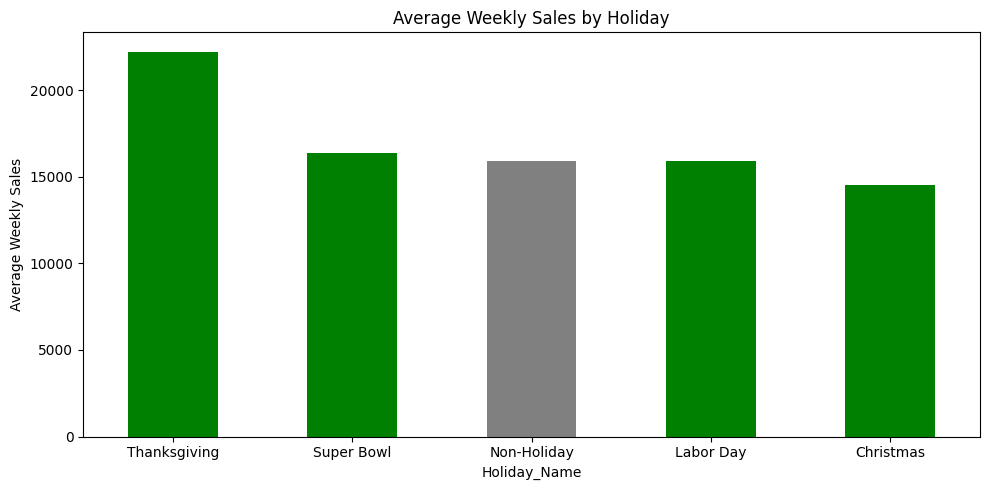

In [38]:
# Bar chart of all holidays
plt.figure(figsize=(10,5))
holiday_means.plot(kind='bar', color=['green' if h != 'Non-Holiday' else 'gray' for h in holiday_means.index])
plt.title('Average Weekly Sales by Holiday')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('holiday_bar_chart.png')
plt.show()

In [39]:
# Run this before the comparison
print(df[df['Date_str'].isin(['2010-12-24', '2011-12-23'])][['Date', 'Weekly_Sales']].head())

           Date  Weekly_Sales
2676 2010-12-24      55931.23
2677 2010-12-24      59889.32
2678 2010-12-24      12080.36
2679 2010-12-24      47893.23
2680 2010-12-24      85676.09


In [40]:
# Pre-Christmas vs flagged Christmas
pre_xmas_dates = ['2010-12-24', '2011-12-23']
flagged_xmas_dates = ['2010-12-31', '2011-12-30']

pre_xmas_sales = df[df['Date_str'].isin(pre_xmas_dates)]['Weekly_Sales'].mean()
flagged_xmas_sales = df[df['Date_str'].isin(flagged_xmas_dates)]['Weekly_Sales'].mean()

print(f"Pre-Christmas (Dec 24 week) avg sales: ${pre_xmas_sales:,.0f}")
print(f"Flagged Christmas (Dec 31 week) avg sales: ${flagged_xmas_sales:,.0f}")

Pre-Christmas (Dec 24 week) avg sales: $26,396
Flagged Christmas (Dec 31 week) avg sales: $14,543


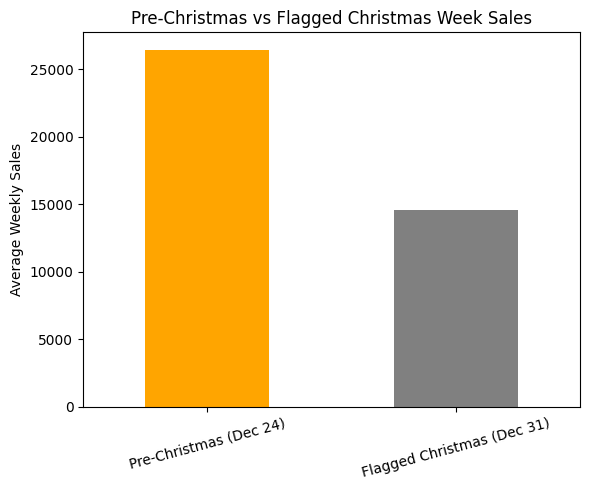

In [41]:
# Visualize Pre-Christmas vs flagged Christmas
comparison = pd.Series({
    'Pre-Christmas (Dec 24)': pre_xmas_sales,
    'Flagged Christmas (Dec 31)': flagged_xmas_sales
})

plt.figure(figsize=(6,5))
comparison.plot(kind='bar', color=['orange', 'gray'])
plt.title('Pre-Christmas vs Flagged Christmas Week Sales')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('pre_xmas_comparison.png')
plt.show()

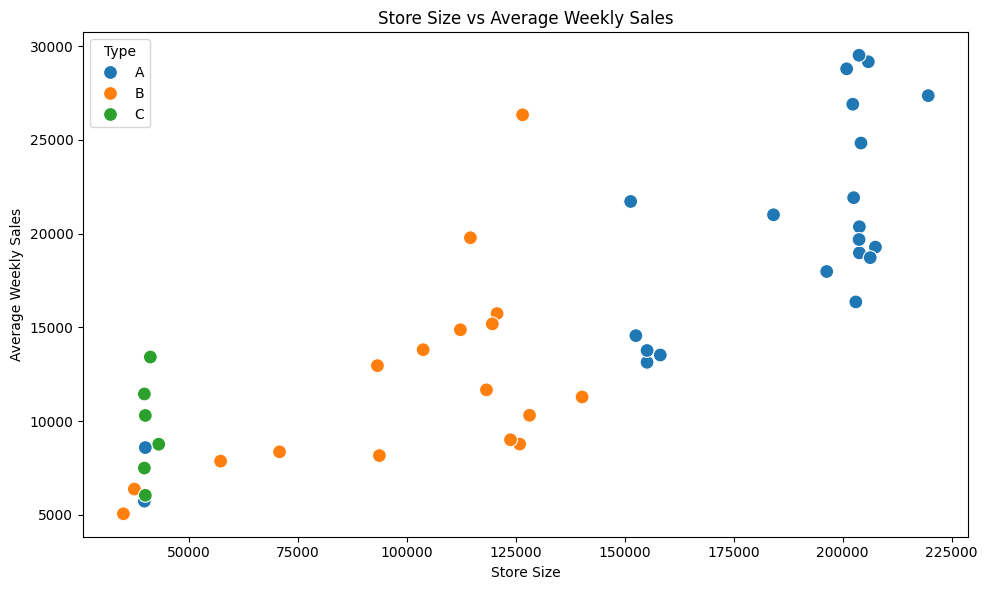

In [42]:
# Scatter plot of Store Size vs Average Weekly Sales
store_avg = df.groupby(['Store', 'Type', 'Size'])['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.scatterplot(data=store_avg, x='Size', y='Weekly_Sales', hue='Type', s=100)
plt.title('Store Size vs Average Weekly Sales')
plt.xlabel('Store Size')
plt.ylabel('Average Weekly Sales')
plt.tight_layout()
plt.savefig('size_vs_sales_scatter.png')
plt.show()

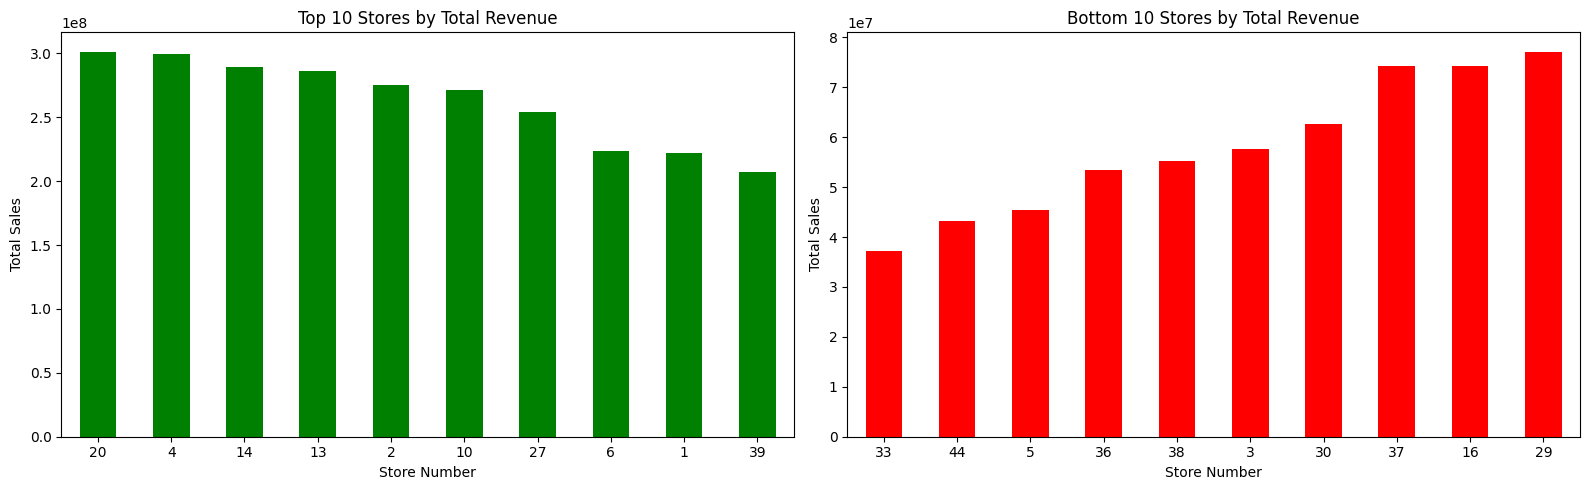

In [43]:
# Bar chart of Top 10 and Bottom 10 stores by total revenue
store_total = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

top10 = store_total.head(10)
bottom10 = store_total.tail(10).sort_values(ascending=True)  # re-sort so worst store is first

fig, axes = plt.subplots(1, 2, figsize=(16,5))

top10.plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title('Top 10 Stores by Total Revenue')
axes[0].set_xlabel('Store Number')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=0)

bottom10.plot(kind='bar', ax=axes[1], color='red')
axes[1].set_title('Bottom 10 Stores by Total Revenue')
axes[1].set_xlabel('Store Number')
axes[1].set_ylabel('Total Sales')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('top_bottom_stores.png')
plt.show()

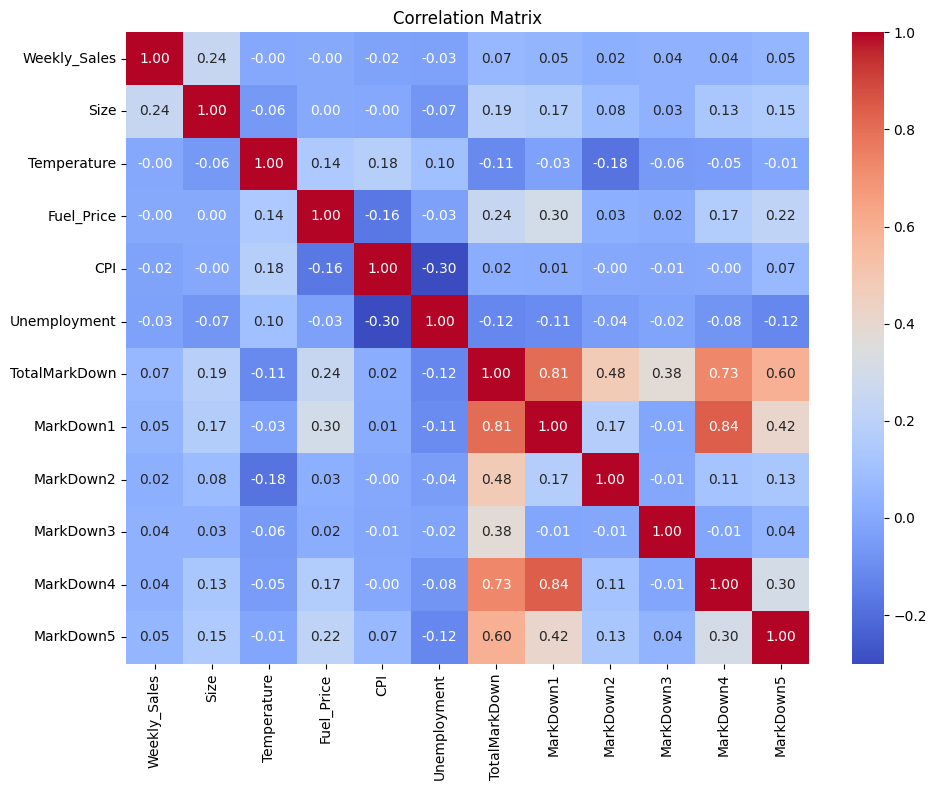

In [44]:
# Heatmap correlation matrix
numeric_cols = ['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price',
                'CPI', 'Unemployment', 'TotalMarkDown',
                'MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [45]:
print(corr['Weekly_Sales'].sort_values(ascending=False))

Weekly_Sales     1.000000
Size             0.243828
TotalMarkDown    0.065236
MarkDown5        0.050465
MarkDown1        0.047172
MarkDown3        0.038562
MarkDown4        0.037467
MarkDown2        0.020716
Fuel_Price      -0.000120
Temperature     -0.002312
CPI             -0.020921
Unemployment    -0.025864
Name: Weekly_Sales, dtype: float64


In [46]:
!pip install missingno

<Figure size 1000x600 with 0 Axes>

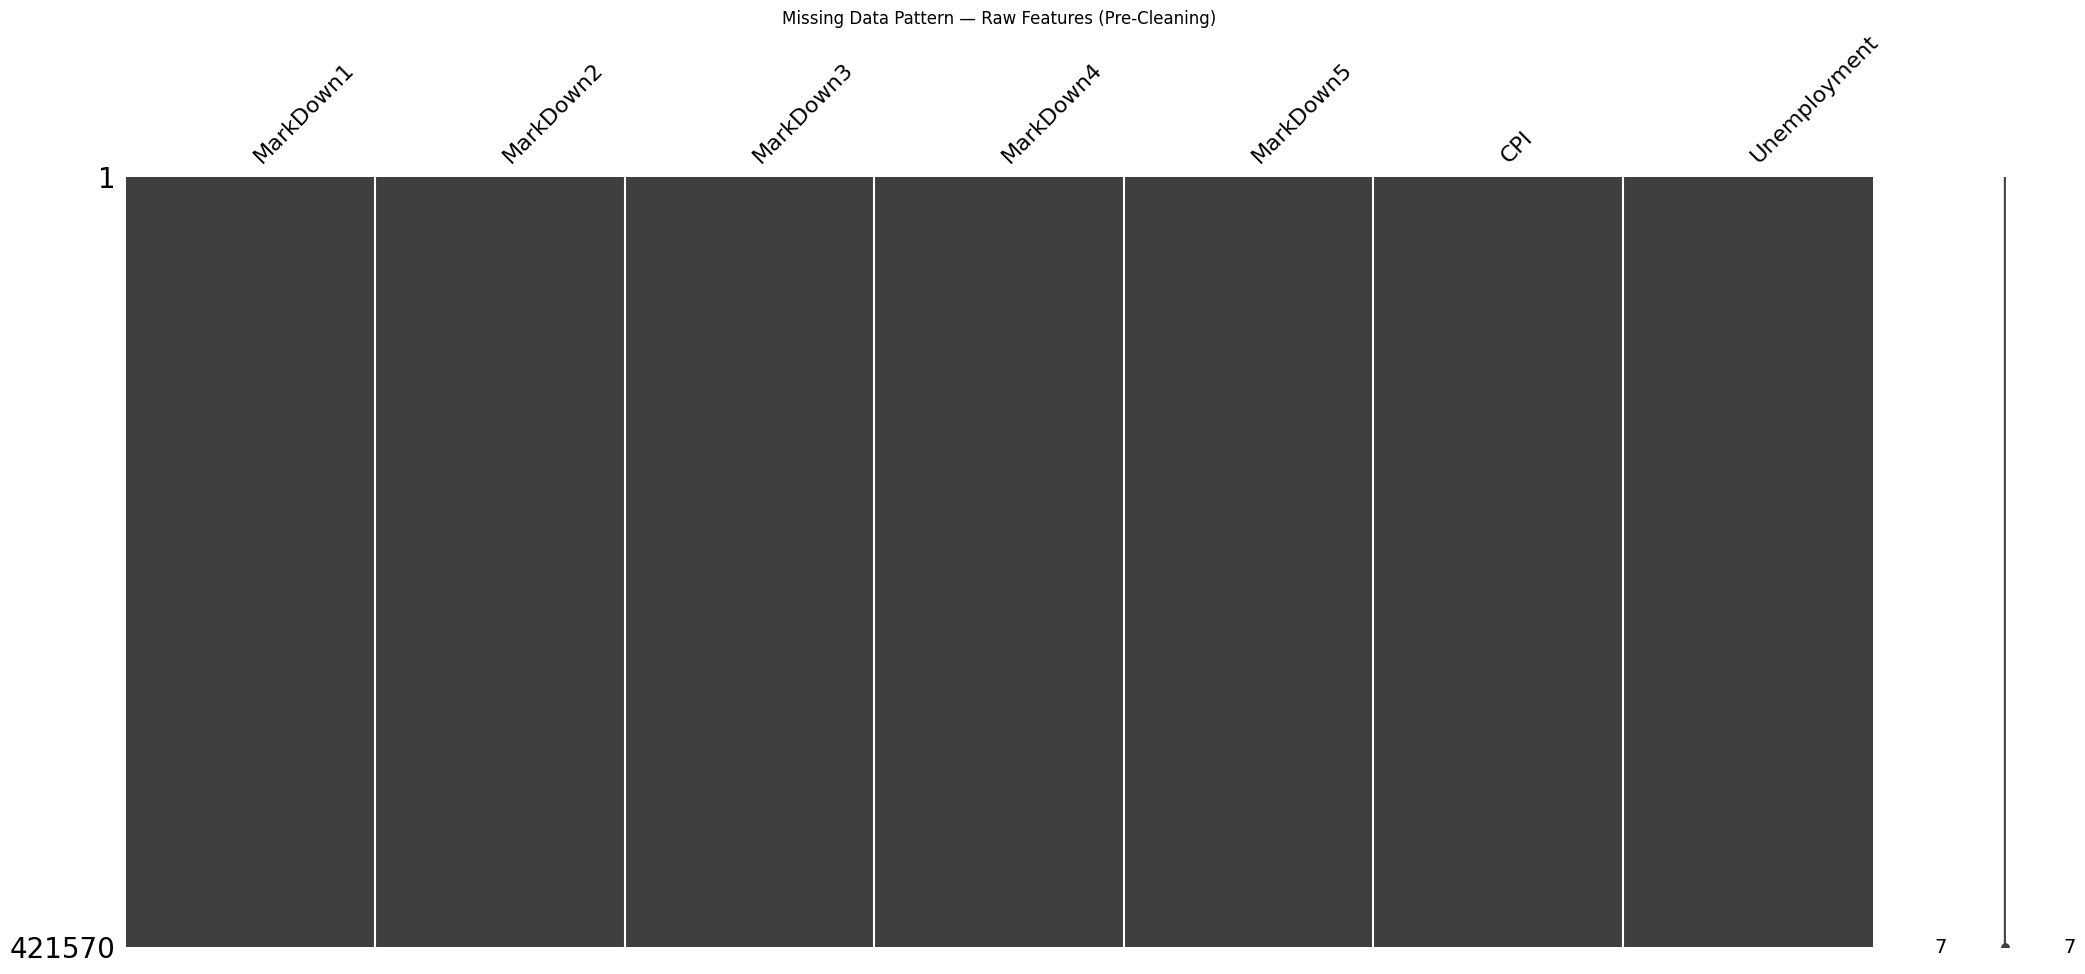

In [47]:
import missingno as msno

plt.figure(figsize=(10,6))
msno.matrix(df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5','CPI','Unemployment']])
plt.title('Missing Data Pattern — Raw Features (Pre-Cleaning)')
plt.savefig('missing_data_matrix.png')
plt.show()

In [48]:
print(df.shape)
print(df['Store'].nunique())
print(df['Date'].nunique())

(421570, 25)
45
143


In [49]:
store_weekly = df.groupby(['Store', 'Date']).agg(
    Weekly_Sales=('Weekly_Sales', 'sum'),
    IsHoliday=('IsHoliday', 'first'),
    Temperature=('Temperature', 'first'),
    Fuel_Price=('Fuel_Price', 'first'),
    CPI=('CPI', 'first'),
    Unemployment=('Unemployment', 'first'),
    TotalMarkDown=('TotalMarkDown', 'sum'),
    Size=('Size', 'first'),
    Type=('Type', 'first')
).reset_index()

print(store_weekly.shape)
print(store_weekly.head())

(6435, 11)
   Store       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1 2010-02-05    1643690.90      False        42.31       2.572   
1      1 2010-02-12    1641957.44       True        38.51       2.548   
2      1 2010-02-19    1611968.17      False        39.93       2.514   
3      1 2010-02-26    1409727.59      False        46.63       2.561   
4      1 2010-03-05    1554806.68      False        46.50       2.625   

          CPI  Unemployment  TotalMarkDown    Size Type  
0  211.096358         8.106              0  151315    A  
1  211.242170         8.106              0  151315    A  
2  211.289143         8.106              0  151315    A  
3  211.319643         8.106              0  151315    A  
4  211.350143         8.106              0  151315    A  


In [50]:
#train/validation split
train_data = store_weekly[store_weekly['Date'] < '2012-05-01']
val_data = store_weekly[store_weekly['Date'] >= '2012-05-01']

print("Train size:", train_data.shape)
print("Val size:", val_data.shape)
print("Train date range:", train_data['Date'].min(), "to", train_data['Date'].max())
print("Val date range:", val_data['Date'].min(), "to", val_data['Date'].max())

Train size: (5265, 11)
Val size: (1170, 11)
Train date range: 2010-02-05 00:00:00 to 2012-04-27 00:00:00
Val date range: 2012-05-04 00:00:00 to 2012-10-26 00:00:00


In [51]:
from sklearn.metrics import mean_absolute_percentage_error

# same week last year
store_weekly_sorted = store_weekly.sort_values(['Store', 'Date'])
store_weekly_sorted['Naive_Forecast'] = store_weekly_sorted.groupby('Store')['Weekly_Sales'].shift(52)

# 4-week moving average baseline
store_weekly_sorted['MA4_Forecast'] = store_weekly_sorted.groupby('Store')['Weekly_Sales'].transform(lambda x: x.shift(1).rolling(4).mean())

# Evaluate on validation period only
val_baseline = store_weekly_sorted[store_weekly_sorted['Date'] >= '2012-05-01'].dropna()

naive_mape = mean_absolute_percentage_error(val_baseline['Weekly_Sales'], val_baseline['Naive_Forecast']) * 100
ma4_mape = mean_absolute_percentage_error(val_baseline['Weekly_Sales'], val_baseline['MA4_Forecast']) * 100

print(f"Naive (Same Week Last Year) MAPE: {naive_mape:.2f}%")
print(f"4-Week Moving Average MAPE: {ma4_mape:.2f}%")

Naive (Same Week Last Year) MAPE: 5.55%
4-Week Moving Average MAPE: 4.62%


In [52]:
!pip install statsmodels

In [53]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error

# Get Store 1 data
store1_train = train_data[train_data['Store'] == 1].set_index('Date')['Weekly_Sales']
store1_val = val_data[val_data['Store'] == 1].set_index('Date')['Weekly_Sales']

# Fit SARIMAX
model = SARIMAX(store1_train, order=(1,1,1), seasonal_order=(1,1,1,52))
result = model.fit(disp=False)

# Forecast
forecast = result.forecast(steps=len(store1_val))

# MAPE
mape = mean_absolute_percentage_error(store1_val, forecast) * 100
print(f"Store 1 ARIMA MAPE: {mape:.2f}%")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Store 1 ARIMA MAPE: 3.59%


In [54]:
!pip install prophet

In [55]:
from prophet import Prophet

# Prepare Store 1 data
store1_prophet_train = train_data[train_data['Store'] == 1][['Date', 'Weekly_Sales']].rename(columns={'Date':'ds', 'Weekly_Sales':'y'})

# Define holidays
holidays = pd.DataFrame({
    'holiday': ['Thanksgiving', 'Thanksgiving',
                'SuperBowl', 'SuperBowl', 'SuperBowl',
                'PreChristmas', 'PreChristmas'],
    'ds': pd.to_datetime([
        '2010-11-26', '2011-11-25',
        '2010-02-12', '2011-02-11', '2012-02-10',
        '2010-12-24', '2011-12-23'
    ]),
    'lower_window': 0,
    'upper_window': 0,
})

# Fit Prophet
m = Prophet(holidays=holidays, yearly_seasonality=True,
            weekly_seasonality=False, daily_seasonality=False)
m.fit(store1_prophet_train)

# Forecast
future = m.make_future_dataframe(periods=len(store1_val), freq='W')
forecast = m.predict(future)

# MAPE
prophet_pred = forecast.tail(len(store1_val))['yhat'].values
prophet_mape = mean_absolute_percentage_error(store1_val.values, prophet_pred) * 100
print(f"Store 1 Prophet MAPE: {prophet_mape:.2f}%")

Store 1 Prophet MAPE: 3.81%


In [56]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

results = []

for store_id in store_weekly['Store'].unique():
    try:
        s_train = train_data[train_data['Store'] == store_id][['Date','Weekly_Sales']].rename(columns={'Date':'ds','Weekly_Sales':'y'})
        s_val = val_data[val_data['Store'] == store_id]['Weekly_Sales'].values

        m = Prophet(holidays=holidays, yearly_seasonality=True,
                    weekly_seasonality=False, daily_seasonality=False)
        m.fit(s_train)

        future = m.make_future_dataframe(periods=len(s_val), freq='W')
        forecast = m.predict(future)
        pred = forecast.tail(len(s_val))['yhat'].values

        mape = mean_absolute_percentage_error(s_val, pred) * 100
        store_type = store_weekly[store_weekly['Store'] == store_id]['Type'].iloc[0]
        store_size = store_weekly[store_weekly['Store'] == store_id]['Size'].iloc[0]

        results.append({'Store': store_id, 'Type': store_type, 'Size': store_size, 'MAPE_Prophet': round(mape, 2)})
        print(f"Store {store_id} done — MAPE: {mape:.2f}%")

    except Exception as e:
        print(f"Store {store_id} failed: {e}")

results_df = pd.DataFrame(results)
print("\nOverall Prophet MAPE:", round(results_df['MAPE_Prophet'].mean(), 2), "%")
print("\nMAPE by Store Type:")
print(results_df.groupby('Type')['MAPE_Prophet'].mean())

Store 1 done — MAPE: 3.81%
Store 2 done — MAPE: 3.12%
Store 3 done — MAPE: 4.44%
Store 4 done — MAPE: 3.12%
Store 5 done — MAPE: 4.13%
Store 6 done — MAPE: 3.41%
Store 7 done — MAPE: 7.14%
Store 8 done — MAPE: 2.88%
Store 9 done — MAPE: 5.23%
Store 10 done — MAPE: 2.57%
Store 11 done — MAPE: 3.48%
Store 12 done — MAPE: 5.14%
Store 13 done — MAPE: 2.55%
Store 14 done — MAPE: 14.55%
Store 15 done — MAPE: 4.37%
Store 16 done — MAPE: 8.13%
Store 17 done — MAPE: 4.74%
Store 18 done — MAPE: 4.28%
Store 19 done — MAPE: 4.02%
Store 20 done — MAPE: 3.79%
Store 21 done — MAPE: 4.77%
Store 22 done — MAPE: 3.35%
Store 23 done — MAPE: 4.31%
Store 24 done — MAPE: 4.70%
Store 25 done — MAPE: 3.63%
Store 26 done — MAPE: 3.53%
Store 27 done — MAPE: 3.72%
Store 28 done — MAPE: 7.85%
Store 29 done — MAPE: 5.57%
Store 30 done — MAPE: 2.68%
Store 31 done — MAPE: 2.38%
Store 32 done — MAPE: 2.30%
Store 33 done — MAPE: 5.45%
Store 34 done — MAPE: 2.54%
Store 35 done — MAPE: 6.80%
Store 36 done — MAPE: 4.66%


In [57]:
# 1. Collect actual vs predicted for all stores
all_preds = []

for store_id in store_weekly['Store'].unique():
    try:
        s_train = train_data[train_data['Store'] == store_id][['Date','Weekly_Sales']].rename(columns={'Date':'ds','Weekly_Sales':'y'})
        s_val = val_data[val_data['Store'] == store_id][['Date','Weekly_Sales']].copy()

        m = Prophet(holidays=holidays, yearly_seasonality=True,
                    weekly_seasonality=False, daily_seasonality=False)
        m.fit(s_train)

        future = m.make_future_dataframe(periods=len(s_val), freq='W')
        forecast = m.predict(future)
        pred = forecast.tail(len(s_val))['yhat'].values

        s_val['Predicted'] = pred
        s_val['Store'] = store_id
        s_val['Type'] = store_weekly[store_weekly['Store'] == store_id]['Type'].iloc[0]
        s_val['Error_Pct'] = abs(s_val['Weekly_Sales'] - s_val['Predicted']) / s_val['Weekly_Sales'] * 100
        all_preds.append(s_val)

    except Exception as e:
        print(f"Store {store_id} failed: {e}")

# Combine all stores
forecast_results = pd.concat(all_preds, ignore_index=True)
forecast_results.columns = ['Date', 'Actual', 'Predicted', 'Store', 'Type', 'Error_Pct']

# Add IsHoliday
forecast_results = forecast_results.merge(
    store_weekly[['Store','Date','IsHoliday']], on=['Store','Date'], how='left')

# 2. Store MAPE summary
store_mape_summary = results_df.copy()

# 3. Export both
forecast_results.to_csv("forecast_results.csv", index=False)
store_mape_summary.to_csv("store_mape_summary.csv", index=False)

print("forecast_results shape:", forecast_results.shape)
print("store_mape_summary shape:", store_mape_summary.shape)
print("Files exported!")

forecast_results shape: (1170, 7)
store_mape_summary shape: (45, 4)
Files exported!


In [58]:
from google.colab import files
files.download("forecast_results.csv")
files.download("store_mape_summary.csv")
files.download("walmart_master.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
print('HasMarkDown' in df.columns)
print('TotalMarkDown' in df.columns)
print(df['HasMarkDown'].value_counts())


True
True
HasMarkDown
False    270138
True     151432
Name: count, dtype: int64


Holiday + Markdown avg sales:    $17,594
Non-Holiday, No Markdown avg:    $16,471
Sales lift: 6.8%


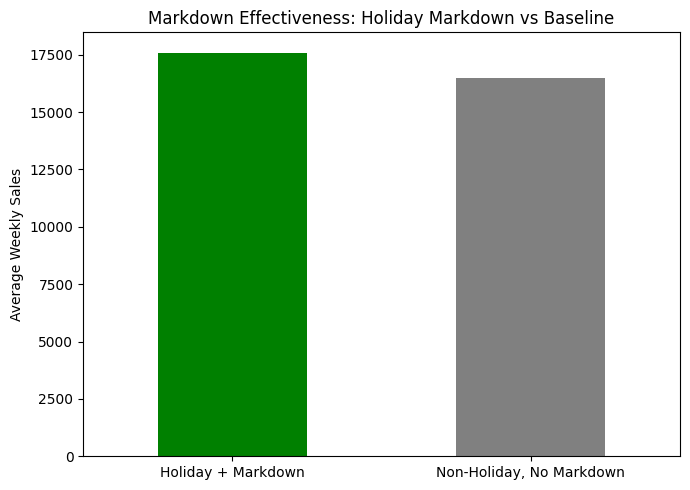

In [60]:
# Step 1: Filter to markdown period only (Nov 2011 onward)
md_period = df[df['Date'] >= '2011-11-01']

# Step 2: Compare holiday weeks WITH markdown vs non-holiday weeks
holiday_md = md_period[(md_period['IsHoliday'] == True) &
                        (md_period['TotalMarkDown'] > 0)]['Weekly_Sales']

non_holiday = md_period[(md_period['IsHoliday'] == False) &
                         (md_period['TotalMarkDown'] == 0)]['Weekly_Sales']

# Step 3: Simple comparison
print(f"Holiday + Markdown avg sales:    ${holiday_md.mean():,.0f}")
print(f"Non-Holiday, No Markdown avg:    ${non_holiday.mean():,.0f}")

lift = (holiday_md.mean() - non_holiday.mean()) / non_holiday.mean() * 100
print(f"Sales lift: {lift:.1f}%")

# Step 4: Bar chart
import matplotlib.pyplot as plt

comparison = pd.Series({
    'Holiday + Markdown': holiday_md.mean(),
    'Non-Holiday, No Markdown': non_holiday.mean()
})
comparison.plot(kind='bar', color=['green', 'gray'], figsize=(7,5))
plt.title('Markdown Effectiveness: Holiday Markdown vs Baseline')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('markdown_effectiveness.png')
plt.show()

In [61]:
# Fix avg weekly sales and validation period
store_avg = store_weekly.groupby('Store')['Weekly_Sales'].mean().reset_index()
store_avg.columns = ['Store', 'Avg_Weekly_Sales']
store_avg['Avg_Weekly_Sales'] = store_avg['Avg_Weekly_Sales'].round(2)

summary = results_df.copy()
summary = summary.merge(store_avg, on='Store')
summary['Best_Model'] = 'Prophet'
summary['Validation_Period'] = 'May 2012 - Oct 2012'

summary.to_csv("store_accuracy_summary.csv", index=False)

from google.colab import files
files.download("store_accuracy_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
print(results_df.shape)
print(results_df.head())

(45, 4)
   Store Type    Size  MAPE_Prophet
0      1    A  151315          3.81
1      2    A  202307          3.12
2      3    B   37392          4.44
3      4    A  205863          3.12
4      5    B   34875          4.13
